In [ ]:
import numpy as np
import json
from typing import List, Dict
import os
import subprocess
from sklearn.preprocessing import normalize
from functools import lru_cache
from sklearn.cluster import MiniBatchKMeans

In [ ]:
@lru_cache(maxsize=None)
def _truncated_zipf_pmf(card: int, a: float) -> np.ndarray:
    """
    P(k) ∝ 1 / k^a  for k=1..card, normalized.
    a>0에서 유한 card에 대해 항상 정상화 가능.
    """
    k = np.arange(1, card + 1, dtype=np.float64)
    p = 1.0 / np.power(k, a)
    p /= p.sum()
    return p.astype(np.float64)

def _sample_labels(rng, distribution, card, size, zipf_param):
    """
    distribution == 'zipf'일 때, 1..card 범위의 truncated-zipf를 직접 샘플링.
    → tail을 card에 clip하지 않으므로 최대값 스파이크 없음.
    """
    if distribution == 'zipf':
        p = _truncated_zipf_pmf(card, float(zipf_param))
        return rng.choice(np.arange(1, card + 1, dtype=np.int32), size=size, p=p)
    elif distribution in ('uniform', 'random'):
        return rng.integers(1, card + 1, size=size, dtype=np.int32)
    else:
        raise ValueError(f"unsupported distribution: {distribution}")

def _permute_by_correlation_keep_multiset(
    rng,
    labels,            # (N,) int32, includes -1 for missing; will be copied
    present_mask,      # (N,) bool
    cluster_ids,       # (N,) int
    corr               # float in [0,1]
):
    """
    전역 라벨 멀티셋(값/개수)은 유지하되, present인 인덱스들만 대상으로
    '누가 어떤 라벨을 가질지'를 재배치한다.
    - 클러스터 정렬: present에서 큰 클러스터일수록 앞쪽으로 배치
    - 라벨 정렬: present 라벨 중 빈도(내림차순) 큰 값부터 블록 배치
    - corr↑일수록 (클러스터 배치와 라벨 블록) 정렬을 더 강하게 반영
    """
    if corr <= 0:
        return labels

    out = labels.copy()

    idx_present = np.flatnonzero(present_mask)
    if idx_present.size == 0:
        return out

    # 1) present 라벨 멀티셋 확보
    present_labels = labels[idx_present]

    # 2) 클러스터 크기 기반 정렬 키 만들기
    cl = cluster_ids[idx_present]
    uniq_cl, inv_cl = np.unique(cl, return_inverse=True)

    # 각 클러스터의 present 샘플 수
    counts_cl = np.bincount(inv_cl, minlength=uniq_cl.size)
    # 큰 클러스터 먼저
    order_cl_by_size = np.argsort(-counts_cl, kind='mergesort')
    # 클러스터ID -> size-rank 매핑
    rank_table = np.empty_like(order_cl_by_size)
    rank_table[order_cl_by_size] = np.arange(order_cl_by_size.size)
    cl_size_rank = rank_table[inv_cl].astype(np.float32)
    denom = max(order_cl_by_size.size, 1)
    cl_rank_norm = cl_size_rank / denom

    # 3) 라벨 멀티셋을 "빈도 내림차순(+값 오름차순)" 블록으로 정렬
    uniq_lab, counts_lab = np.unique(present_labels, return_counts=True)
    order_lab = np.lexsort((uniq_lab, -counts_lab))  # (-count, value)
    lab_vals_sorted = uniq_lab[order_lab]
    lab_cnts_sorted = counts_lab[order_lab]
    labels_sorted = np.repeat(lab_vals_sorted, lab_cnts_sorted)

    # 4) corr로 클러스터 정렬과 랜덤 혼합
    noise = rng.random(idx_present.size, dtype=np.float32)
    blended = (1.0 - corr) * noise + corr * (cl_rank_norm + 1e-6 * noise)

    order_idx = np.argsort(blended, kind='mergesort')
    target_indices = idx_present[order_idx]

    # 5) 재배치
    out[target_indices] = labels_sorted
    return out

def generate_attribute_payloads(
    num_vectors,
    num_attributes,
    cardinalities,
    missing_prob,
    base_vectors=None,
    correlations=None,   # [0, 1] 범위
    distribution='zipf',
    zipf_param=1.5,
    missing_value=-1,
    seed=42,
):
    """
    절차:
    1) 각 attribute에 대해 전역 분포(distribution)로 raw 라벨 생성 + missing 적용 → payload 채움
    2) '모든 attribute가 missing'인 행을 먼저 보정 (전역 분포 유지)
    3) 각 attribute별로, cardinality 개수만큼 클러스터링(K=card) 수행
    4) 라벨 멀티셋은 그대로 보존하면서, corr에 비례해 '누가 어떤 라벨을 받는지'만 재배치
    """
    assert len(cardinalities) == num_attributes, "카디널리티 길이가 attribute 수와 일치해야 합니다."
    rng_root = np.random.default_rng(seed)

    # ----------- 입력 벡터 준비 -----------
    if base_vectors is None:
        base_vectors = rng_root.normal(size=(num_vectors, 16)).astype(np.float32)
    X = normalize(base_vectors.astype(np.float32))

    # ----------- 1) raw 생성(전역 분포) + missing 적용 -----------
    payloads = np.full((num_vectors, num_attributes), missing_value, dtype=np.int32)
    present_masks = np.zeros((num_vectors, num_attributes), dtype=bool)

    for a in range(num_attributes):
        rng = np.random.default_rng(seed + 1000 + a)
        card = cardinalities[a]
        # 전역 분포로 라벨 생성 (truncated Zipf)
        raw = _sample_labels(rng, distribution, card, size=num_vectors, zipf_param=zipf_param)
        # missing 적용
        present = (rng.random(num_vectors) > missing_prob[a])
        payloads[present, a] = raw[present]
        present_masks[:, a] = present

    # ----------- 2) 모든 attribute가 missing인 행 보정 -----------
    all_missing = np.all(~present_masks, axis=1)
    if np.any(all_missing):
        rows = np.flatnonzero(all_missing)
        cols = rng_root.integers(0, num_attributes, size=rows.size)
        for r, c in zip(rows, cols):
            rng = np.random.default_rng(seed + 2000 + c)
            card = cardinalities[c]
            val = _sample_labels(rng, distribution, card, size=1, zipf_param=zipf_param)[0]
            payloads[r, c] = val
            present_masks[r, c] = True

    # ----------- 3) corr 반영: 멀티셋 보존 재배치 -----------
    if correlations is None:
        correlations = np.zeros(num_attributes, dtype=np.float32)

    for a in range(num_attributes):
        corr = float(correlations[a])
        if corr <= 0:
            continue

        card = cardinalities[a]
        rng = np.random.default_rng(seed + 3000 + a)

        # (a) 이 attribute 전용 클러스터링: K=card
        km = MiniBatchKMeans(
            n_clusters=card,
            random_state=seed + 4000 + a,
            batch_size=10000
        )
        cluster_ids = km.fit_predict(X)

        # (b) 멀티셋 보존 재배치(결측 제외)
        col = payloads[:, a]
        present_mask = (col != missing_value)
        col_new = _permute_by_correlation_keep_multiset(
            rng=rng,
            labels=col,
            present_mask=present_mask,
            cluster_ids=cluster_ids,
            corr=corr
        )
        payloads[:, a] = col_new

    return payloads


def generate_query_payloads(
    num_vectors,
    num_attributes,
    cardinalities,
    missing_prob,
    distribution='zipf',
    zipf_param=1.5,
    missing_value=-1,
):
    assert len(cardinalities) == num_attributes, "카디널리티 길이가 attribute 수와 일치해야 합니다."

    payloads = np.full((num_vectors, num_attributes), missing_value, dtype=int)

    for i in range(num_attributes):
        card = cardinalities[i]
        present_mask = np.random.rand(num_vectors) > missing_prob[i]

        if distribution == 'zipf':
            raw = np.random.zipf(zipf_param, size=num_vectors)
            raw = np.clip(raw, 1, card)
        elif distribution == 'random':
            raw = np.random.randint(1, card + 1, size=num_vectors)
        else:
            raise ValueError(f"지원하지 않는 분포: {distribution}")

        payloads[present_mask, i] = raw[present_mask]

    # ✅ 모든 attribute가 missing인 벡터 보정
    for idx in range(num_vectors):
        if np.all(payloads[idx] == missing_value):
            # 랜덤 attribute 하나 선택해서 채우기
            i = np.random.randint(0, num_attributes)
            card = cardinalities[i]
            if distribution == 'zipf':
                val = np.clip(np.random.zipf(zipf_param), 1, card)
            elif distribution == 'random':
                val = np.random.randint(1, card + 1)
            payloads[idx, i] = val

    return payloads












def payloads_to_dicts(payloads, prefix="label", include_missing=True):
    """
    Convert attribute payloads to list of dicts.

    Args:
        payloads (np.ndarray): (N, A) array of attribute values
        prefix (str): key prefix (default: "label")
        include_missing (bool): whether to include -1 in output dicts

    Returns:
        List[Dict[str, int]]
    """
    num_vectors, num_attributes = payloads.shape
    dict_list = []

    for i in range(num_vectors):
        d = {}
        for j in range(num_attributes):
            val = payloads[i, j]
            if include_missing or val != -1:
                d[f"{prefix}_{j+1}"] = int(val)
        dict_list.append(d)
    return dict_list

def build_label_mapping(filter_dict: dict, mapping_json_path: str):
    """
    filters.json 안의 각 entry(name) 아래 values 문자열에 대해
    (name, value) 쌍별로 0부터 시작하는 고유 ID를 매핑하고,
    매핑 결과를 JSON 파일로 저장합니다.
    """
    # 1) filters.json 로드
    
    filters = filter_dict

    mapping = {}
    next_id = 1

    # 2) (name, value) 쌍별로 ID 할당
    for temp in filters:
        for key, value in temp.items():
            if (key, value) not in mapping:
                mapping[(key, value)] = next_id
                next_id += 1
            
    # 3) 문자열 키로 변환
    str_mapping = { f"{name}:{val}": idx for (name, val), idx in mapping.items() }

    # 4) 매핑을 JSON 파일로 저장
    with open(mapping_json_path, 'w', encoding='utf-8') as out:
        json.dump(str_mapping, out, ensure_ascii=False, indent=2)

    print(f"Saved {len(str_mapping)} mappings to '{mapping_json_path}'. Max ID = {next_id - 1}")
    return mapping_json_path



def save_vector_label(
    vector_payload: List[Dict],
    mapping_json_path: str,
    output_txt_path: str
):
    """
    - payload_jsonl_path: JSONL 파일 경로, 각 줄이 {"label_1": 1, ...} 형태
    - mapping_json_path: "label:value" → id 매핑이 들어 있는 JSON 경로
    - output_txt_path: 결과를 저장할 .txt 경로

    결과는 각 payload를 ID로 매핑해서 콤마로 연결, 한 줄씩 저장.
    """
    # 매핑 로드
    with open(mapping_json_path, 'r', encoding='utf-8') as f:
        mapping = json.load(f)

    with open(output_txt_path, 'w', encoding='utf-8') as fout:
        for i, payload in enumerate(vector_payload):
            ids = []
            for key, value in payload.items():
                map_key = f"{key}:{value}"
                if map_key not in mapping:
                    raise ValueError(f"[Line {i}] mapping.json에 {map_key}이 없습니다.")
                ids.append(str(mapping[map_key]))
            fout.write(','.join(ids) + '\n')

    print(f"[✓] 라벨 텍스트 저장 완료: {output_txt_path}")


def read_fvecs(path):
    a = np.fromfile(path, dtype=np.int32)
    dim = a[0]
    if (a.size % (dim + 1)) != 0:
        raise RuntimeError("fvecs file corrupted or wrong dimension")
    return a.reshape(-1, dim + 1)[:, 1:].view('float32')


def save_compute_groundtruth(
    base_label_file,
    query_label_file,
    gt_file,
    query_bin_file,
    base_bin_file,
    build_dir = "/home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build",
    data_type = "float",
    dist_fn = "L2",
    scenario = "containment",
    K = 10,
    num_threads = 200,
):
    cmd = [
        f"{build_dir}/tools/compute_groundtruth",
        "--data_type", str(data_type),
        "--dist_fn", str(dist_fn),
        "--scenario", str(scenario),
        "--K", str(K),
        "--num_threads", str(num_threads),
        "--base_bin_file", str(base_bin_file),
        "--base_label_file", str(base_label_file),
        "--query_bin_file", str(query_bin_file),
        "--query_label_file", str(query_label_file),
        "--gt_file", str(gt_file)
    ]
    print("[명령 실행] " + " \\\n    ".join(cmd))
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def load_groundtruth_bin(filename, nq):
    record_dtype = np.dtype([("idx", np.uint32), ("dist", np.float32)])
    file_size = os.path.getsize(filename)
    record_size = record_dtype.itemsize  # 8 bytes (4+4)
    total_recs = file_size // record_size

    if nq == 0 or total_recs % nq != 0:
        raise ValueError(f"GT file size mismatch: total_recs={total_recs}, nq={nq}")

    K_gt = total_recs // nq

    data = np.fromfile(filename, dtype=record_dtype, count=total_recs)
    # 인덱스만 추출, shape: (nq, K_gt)
    gt_indices = data["idx"].reshape(nq, K_gt)
    return gt_indices

In [14]:
dataset_name = "gist1m"
dataset_name = "sift1m"
# dataset_name = "glove1m"

num_attribute = 29
cardinality = [1] * num_attribute
# cardinality = [100,20,10,5,3,2]
# base_distribution = "zipf"
base_distribution = "random"
query_distribution = "random"
base_missing_prob = [0.5] * num_attribute
# base_missing_prob = [0.0, 0.5, 0.8]
query_missing_prob = [0.9] * num_attribute
correlation = [0.0] * num_attribute
# correlation = [0.0,0.5,1.0]
original_data_path = f"/home/ec2-user/hybrid_hardness/Benchmark/{dataset_name}_original"

In [ ]:
cardi = '_'.join(str(c) for c in cardinality)
missing = '_'.join(str(c) for c in base_missing_prob)
corr = '_'.join(str(c) for c in correlation)


target_path = f"/home/ec2-user/hybrid_hardness/Benchmark/{dataset_name}_A{num_attribute}_{cardi}_{base_distribution}_{missing}_{corr}"
# target_path = f"/home/ec2-user/hybrid_hardness/Benchmark/test_29"
os.makedirs(target_path, exist_ok=True)


hardness_path = os.path.join(target_path, "hardness_format")
os.makedirs(hardness_path, exist_ok=True)


mid_path = os.path.join(target_path, "mid_format")
os.makedirs(mid_path, exist_ok=True)



content = (
    f"num_attribute = {num_attribute}\n"
    f"cardinality = {cardinality}\n"
    f"base_distribution = {base_distribution}\n"
    f"query_distribution = {query_distribution}\n"
    f"correlation = {correlation}\n"
    f"base_missing_prob = {base_missing_prob}\n"
    f"query_missing_prob = {query_missing_prob}\n"
)

# 저장
file_path = os.path.join(target_path, "info.txt")
with open(file_path, "w") as f:
    f.write(content)

In [16]:
## save payloads

base_vector_npy = read_fvecs(os.path.join(original_data_path, f"{dataset_name}_base.fvecs")) 
query_vector_npy = read_fvecs(os.path.join(original_data_path, f"{dataset_name}_query.fvecs")) 

## vector.npy를 hardness 에 저장
np.save(os.path.join(hardness_path, "vectors.npy"), base_vector_npy) 

num_base_vector = len(base_vector_npy)
num_query_vector = len(query_vector_npy)

print("base payload generation start ... ")

base_label_arr = generate_attribute_payloads(
        num_vectors=len(base_vector_npy),
        num_attributes=num_attribute,
        cardinalities=cardinality,
        base_vectors=base_vector_npy,
        correlations=correlation,
        distribution=base_distribution,
        zipf_param=1.5,
        missing_prob=base_missing_prob,
        missing_value=-1
    )

print("base payload generation done")

base_label_payload = payloads_to_dicts(base_label_arr, include_missing=True)
base_label_payload_UNG = payloads_to_dicts(base_label_arr, include_missing=False)

with open(os.path.join(hardness_path, "payloads.jsonl"), "w", encoding="utf-8") as f:
    for payload in base_label_payload:
        f.write(json.dumps(payload, ensure_ascii=False) + "\n")

with open(os.path.join(hardness_path, "payloads_UNG.jsonl"), "w", encoding="utf-8") as f:
    for payload in base_label_payload_UNG:
        f.write(json.dumps(payload, ensure_ascii=False) + "\n")

print(f"base vector payload saved at {hardness_path}")

base payload generation start ... 
base payload generation done
base vector payload saved at /home/ec2-user/hybrid_hardness/Benchmark/test_29/hardness_format


In [17]:
mapping_path = build_label_mapping(base_label_payload, os.path.join(mid_path, "mapping.json"))
# mapping_path_UNG = build_label_mapping(base_label_payload_UNG, os.path.join(mid_path, "mapping_UNG.json"))

Saved 58 mappings to '/home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/mapping.json'. Max ID = 58


In [18]:
base_vector_fvecs = os.path.join(original_data_path, f"{dataset_name}_base.fvecs")
query_vector_fvecs = os.path.join(original_data_path, f"{dataset_name}_query.fvecs")

base_vector_bin = os.path.join(mid_path, "base_vector.bin")
query_vector_bin = os.path.join(mid_path, "query_vector.bin")


subprocess.run([
        "/home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build/tools/fvecs_to_bin",
        "--data_type", "float",
        "--input_file", base_vector_fvecs,
        "--output_file", base_vector_bin
    ], check=True)


subprocess.run([
        "/home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build/tools/fvecs_to_bin",
        "--data_type", "float",
        "--input_file", query_vector_fvecs,
        "--output_file", query_vector_bin
    ], check=True)

Dataset: #pts = 1000000, # dims = 128


Dataset: #pts = 10000, # dims = 128


CompletedProcess(args=['/home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build/tools/fvecs_to_bin', '--data_type', 'float', '--input_file', '/home/ec2-user/hybrid_hardness/Benchmark/sift1m_original/sift1m_query.fvecs', '--output_file', '/home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_vector.bin'], returncode=0)

In [19]:
save_vector_label(base_label_payload, mapping_path, os.path.join(mid_path, "base_label.txt"))
save_vector_label(base_label_payload_UNG, mapping_path, os.path.join(mid_path, "base_label_UNG.txt"))

[✓] 라벨 텍스트 저장 완료: /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_label.txt
[✓] 라벨 텍스트 저장 완료: /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_label_UNG.txt


In [ ]:
target_value = 4294967295
valid_query_labels = []

iteraion_count = 0
while len(valid_query_labels) < 10000:
    print("len of valid query labels: ", len(valid_query_labels))
    iteraion_count += 1
    query_label_arr = generate_query_payloads(
            10000,
            num_attribute,
            cardinality,
            query_missing_prob,
            "random",
        )
    query_label_payload = payloads_to_dicts(query_label_arr, include_missing=False)
    save_vector_label(query_label_payload, mapping_path, os.path.join(mid_path, "query_label.txt"))
    query_labels = []
    with open(os.path.join(mid_path, "query_label.txt"), 'r') as f:
        for line in f:
            # 공백 제거 후 쉼표 기준으로 분리
            parts = line.strip().split(',')
            # 비어 있지 않은 경우만 정수형으로 변환
            if parts and parts[0] != '':
                query_labels.append([int(x) for x in parts])
    save_compute_groundtruth(
        os.path.join(mid_path, "base_label.txt"),
        os.path.join(mid_path, "query_label.txt"),
        os.path.join(mid_path, "gt.bin"),
        query_vector_bin,
        base_vector_bin
    )
    gt_indices= load_groundtruth_bin(os.path.join(mid_path, "gt.bin"), num_query_vector)
    gt_indices = gt_indices.tolist()

    valid_indices = [
        i for i, sublist in enumerate(gt_indices)
        if not all(v == target_value for v in sublist)
    ]
    # print(valid_indices)
    print("len of valid query label in current iteration: ", len(valid_indices))
    filtered_query_labels = [query_label_payload[i] for i in valid_indices]
    valid_query_labels += filtered_query_labels
    if len(valid_query_labels) > 10000:
        valid_query_labels = valid_query_labels[:10000]
        print("len of valid query labels: ", len(valid_query_labels))
        break

    # print(len(filtered_query_labels))  # 남은 항목 개수 확인
print("iteration count: ", iteraion_count)
save_vector_label(valid_query_labels, mapping_path, os.path.join(mid_path, "query_label.txt"))

save_compute_groundtruth(
    os.path.join(mid_path, "base_label.txt"),
    os.path.join(mid_path, "query_label.txt"),
    os.path.join(mid_path, "gt.bin"),
    query_vector_bin,
    base_vector_bin
)
gt_indices= load_groundtruth_bin(os.path.join(mid_path, "gt.bin"), num_query_vector)
gt_indices = gt_indices.tolist()

valid_indices = [
    i for i, sublist in enumerate(gt_indices)
    if not all(v == target_value for v in sublist)
]

print("number of valid query labels: ",len(valid_indices))

len of valid query labels:  0
[✓] 라벨 텍스트 저장 완료: /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_label.txt
[명령 실행] /home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build/tools/compute_groundtruth \
    --data_type \
    float \
    --dist_fn \
    L2 \
    --scenario \
    containment \
    --K \
    10 \
    --num_threads \
    200 \
    --base_bin_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_vector.bin \
    --base_label_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_label.txt \
    --query_bin_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_vector.bin \
    --query_label_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_label.txt \
    --gt_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/gt.bin


len of valid query label in current iteration:  10000
iteration count:  1
[✓] 라벨 텍스트 저장 완료: /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_label.txt
[명령 실행] /home/ec2-user/hybrid_hardness/methods/Unified-Navigating-Graph/build/tools/compute_groundtruth \
    --data_type \
    float \
    --dist_fn \
    L2 \
    --scenario \
    containment \
    --K \
    10 \
    --num_threads \
    200 \
    --base_bin_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_vector.bin \
    --base_label_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/base_label.txt \
    --query_bin_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_vector.bin \
    --query_label_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/query_label.txt \
    --gt_file \
    /home/ec2-user/hybrid_hardness/Benchmark/test_29/mid_format/gt.bin


In [ ]:
conditions = []

for query_label in valid_query_labels:
    temp = {}
    temp["and"] = []
    for key, value in query_label.items():    
        temp["and"].append({key: {"match" : {"value": value}}})
    conditions.append(temp)

In [ ]:
## save tests

tests = []
query_vector_array = query_vector_npy.tolist()
for query, condition, gt in zip(query_vector_array, conditions, gt_indices):
    temp = {}
    temp["query"] = query
    temp["conditions"] = condition
    temp["closest_ids"] = gt
    tests.append(temp)

with open(os.path.join(hardness_path, "tests.jsonl"), "w", encoding="utf-8") as f:
    for item in tests:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

In [ ]:
# dataset_name = "sift1m"
# # num_attribute = 6
# # cardinality = [6]*num_attribute
# cardi = '_'.join(str(c) for c in cardinality)

# dataset_path = f"/home/mintaek/hybrid_index/Benchmark/sift1m_A{num_attribute}_{cardi}_{base_distribution}"
dataset_path = target_path
# mid_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_A{num_attribute}_{cardi}_{base_distribution}/mid_format"


DATA_DIR = os.path.join(dataset_path, "hardness_format")

# DATA_DIR = "/home/mintaek/hybrid_index/Benchmark/generated_12_high"


tests_file = f"{DATA_DIR}/tests.jsonl"
tests = []
with open(tests_file, "r") as f:
    for line in f:
        tests.append(json.loads(line))

print(f"Loaded {len(tests)} tests")


Loaded 10000 tests


In [ ]:
count = []
for test in tests:
    ids = test["closest_ids"]
    num_valid = sum(x != 4294967295 for x in ids)
    count.append(num_valid)

with open(os.path.join(mid_path, "count.txt"), "w") as f:
    for c in count:
        f.write(f"{c}\n")

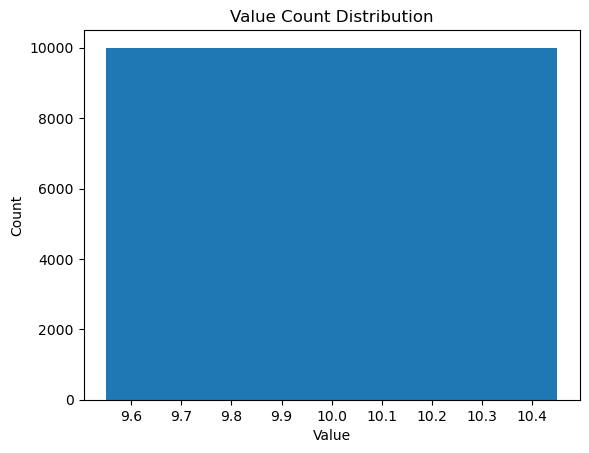

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from collections import Counter

counts = Counter(count)

# 라벨을 정수로 변환 + 정렬
labels = sorted(int(k) for k in counts.keys())
values = [counts[k] for k in labels]

fig, ax = plt.subplots()
ax.bar(labels, values, width=0.9, align='center')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.set_title('Value Count Distribution')

# x축을 정수 눈금으로
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# 라벨 겹치면 회전
plt.xticks(rotation=0)

plt.show()
